In [130]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 256
L = 2.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

In [131]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))
sfs = []
bin_sfs = []
ospecs = []
mspecs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, lenn=phys_dims)
    _ko, _feko, wo = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nansum, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_loc='center',
            cut_excess=True, nan_small=False)
    ospecs.append((_ko, _feko, wo))
    _km, _fekm, wm = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_loc='center',
            cut_excess=True, nan_small=False)
    mspecs.append((_km, _fekm, wm))

    lv = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
    sf = strfn.process_lags(f, f, lv, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=True)[0]
    sfs.append(sf)

    lvm = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx

    bin_l, bin_sf, w = statistics_base.bin_data(lvm, sf, bin_func=np.nanmean,
        cut_excess=True, nan_small=False,
        min_bin=dx, bin_loc='center')

    bin_sfs.append((bin_l, bin_sf, w))

    e_parsevals1 = np.nanmax(sf)/2.
    e_parsevals2 = np.nanmax(bin_sf[-1])/2.

    plt.scatter(alphas[i], e_parsevals1/energies[i], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    plt.scatter(alphas[i], e_parsevals2/energies[i], marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

plt.yscale('log')
#plt.ylim((9e-1, 1.1e0))

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats

In [ ]:
cols = plt.cm.Greys(np.linspace(0.5, 1., NUM))

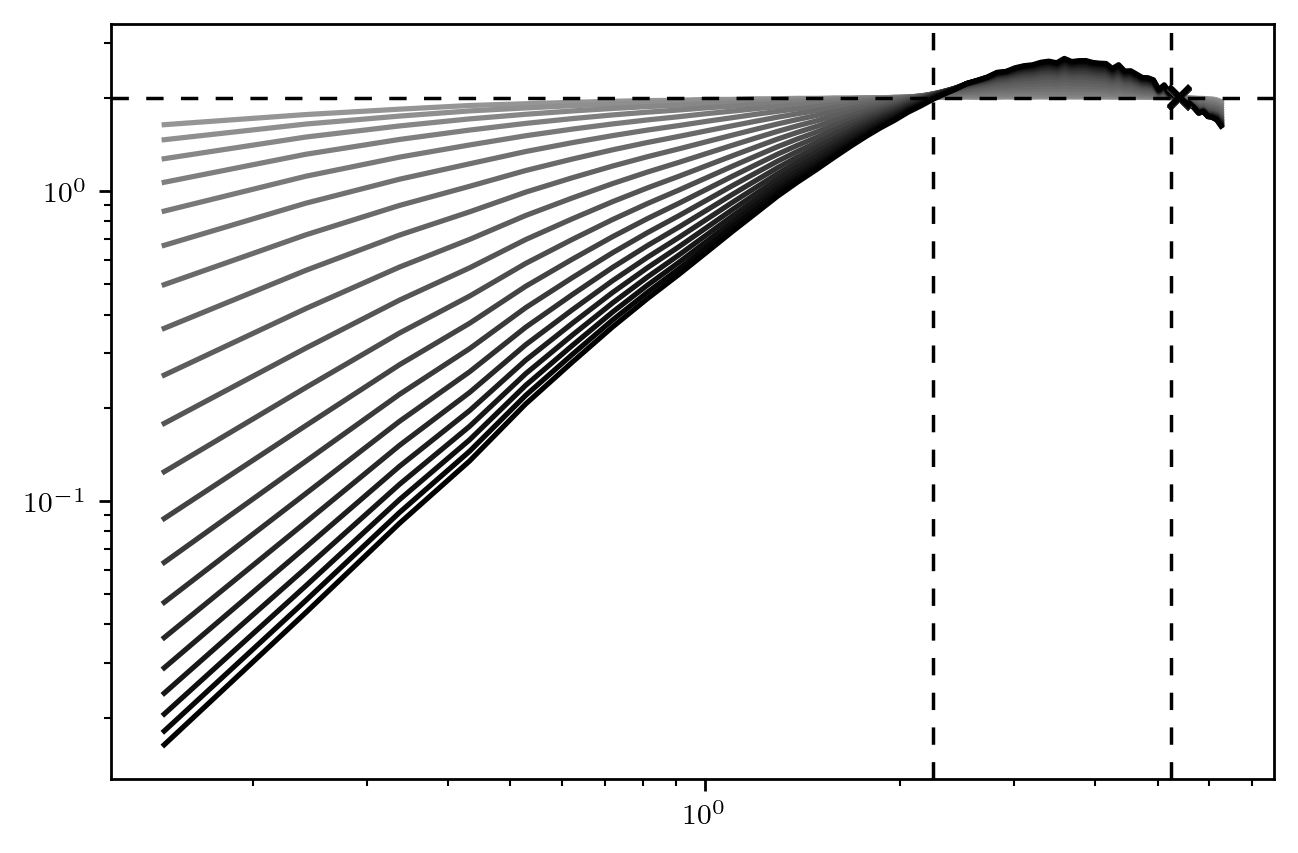

In [ ]:
for i, lsf in enumerate(bin_sfs):
    bin_l, bin_sf, w = lsf
    plt.loglog(bin_l, bin_sf, zorder=0, color=cols[i])
    mmax = bin_sf[N]#np.nanmax(bin_sf)
    idx = np.where(bin_sf == mmax)
    plt.scatter(bin_l[idx], bin_sf[idx], zorder=1, marker='x', color=cols[i])

plt.axhline(2., color='black', linestyle=(0, (5,5)), linewidth=1.)
plt.axvline(L/1.2, color='black', linestyle=(0, (5,5)), linewidth=1.)
plt.axvline(L/2.8, color='black', linestyle=(0, (5,5)), linewidth=1.)

In [ ]:
def omni_spectrum_2(ell, sf2, phys_dims, grid_dims):
    dS = np.gradient(sf2, dx)
    #dell = np.gradient(ell, dx)
    fek = (ell)**2 * (dS) * (twopi**D / 4.)# * (twopi)
    kk = 1. / ell #=*twopi
    return kk[::-1], fek[::-1]

def omni_spectrum(ell, sf2, phys_dims, grid_dims):
    kk = 1. / ell #*twopi
    fek = (twopi**D / 4.) * sf2 * ell# * (twopi)
    return kk[::-1], fek[::-1]


/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/strfn_spectra.py:32: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')


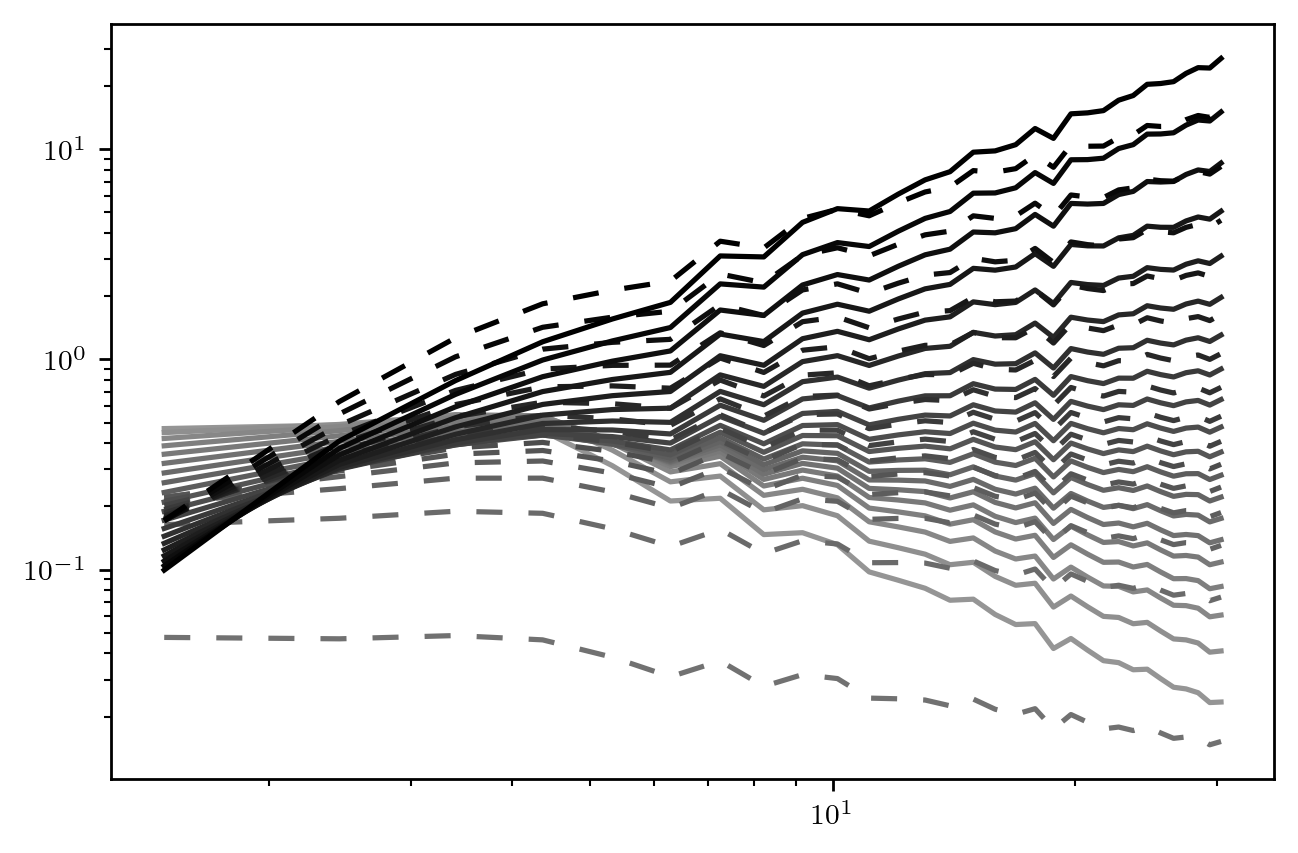

In [ ]:
for i in range(len(sfs)):
    bin_l, bin_sf, w = bin_sfs[i]
    k, fek = omni_spectrum_2(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])
    plt.loglog(ospecs[i][0], int_fek / ospecs[i][1], color=cols[i])

    k, fek = omni_spectrum(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])
    plt.loglog(ospecs[i][0], int_fek * (-alphas[i] - D) / ospecs[i][1], linestyle=(0,(5,5)), color=cols[i])

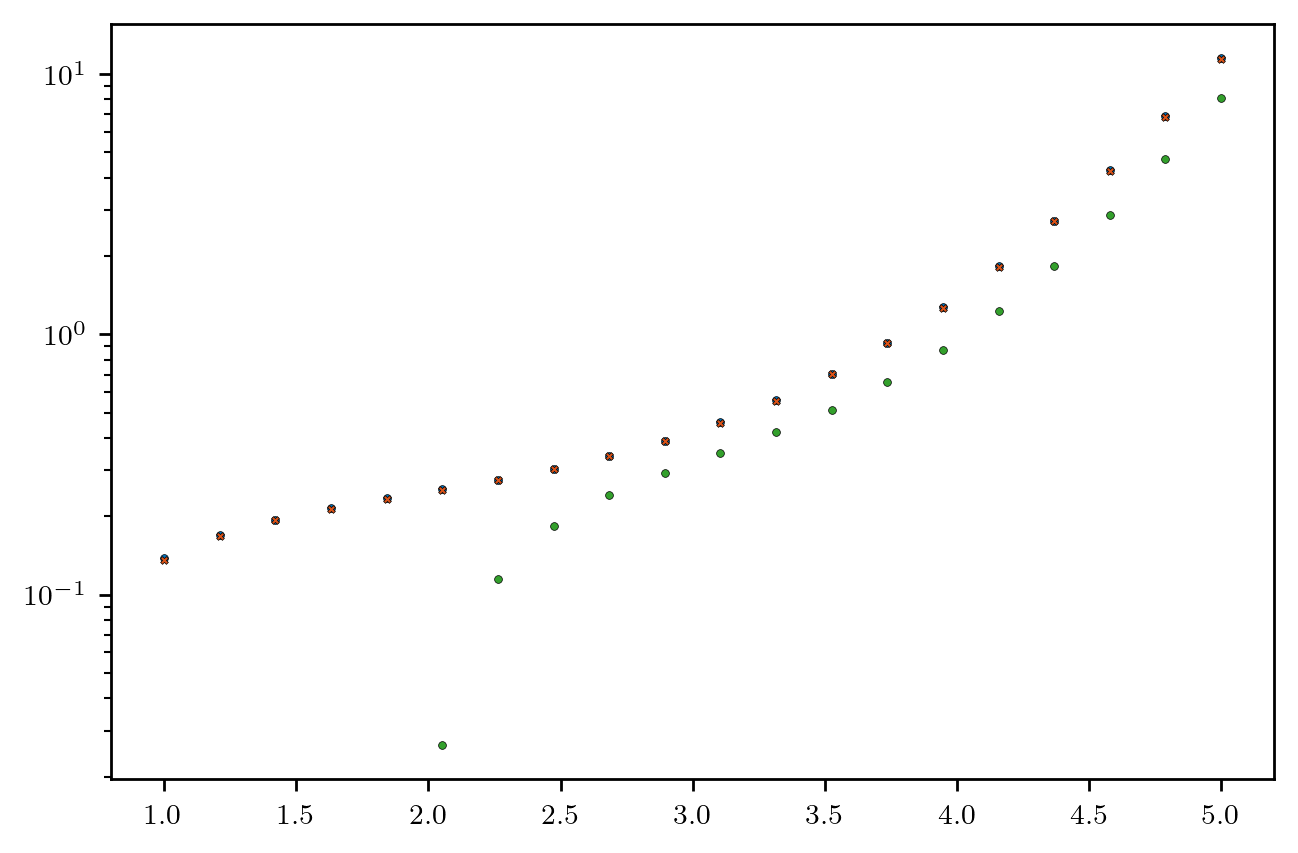

In [ ]:
for i in range(len(sfs)):
    bin_l, bin_sf, w = bin_sfs[i]
    k, fek = omni_spectrum_2(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])
    plt.scatter(-alphas[i], np.nanmean(int_fek / ospecs[i][1] / ospecs[i][2]), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

    int_fekm = int_fek / statistics_base.kern_center(ospecs[i][0], D, ospecs[i][2], dk)
    plt.scatter(-alphas[i], np.nanmean(int_fekm / mspecs[i][1] / mspecs[i][2]), marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

    k, fek = omni_spectrum(bin_l, bin_sf, phys_dims, grid_dims)
    int_fek = strfn_spectra.interpolate(k, fek, ospecs[i][0])

    plt.scatter(-alphas[i], np.nanmean(int_fek * (-alphas[i] - D) / ospecs[i][1] / ospecs[i][2]), marker='o', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')
    #/ (alphas[i] + 2)

plt.yscale('log')